# YZ50 Hafta 8, Görev 4: Türkçe Metinle Eğitim (Tutunamayanlar)

Bu notebook **tek parça** çalışır: `Runtime → Change runtime type → T4 GPU` seç, sonra `Runtime → Run all`. Toplam süre T4'te yaklaşık 12-15 dakikadır.

**Ne yapıyoruz?**

| Adım | İçerik |
|---|---|
| 1 | Oğuz Atay'ın *Tutunamayanlar* romanını internetten indirir (OCR'dan çıkmış metin) |
| 2 | Metni temizler (satır sonu tireleri, sayfa numaraları, tekrar eden başlıklar, garip karakterler) |
| 3 | Romandan **yaklaşık 1,1 milyon karakterlik** (Tiny Shakespeare boyutunda) bir veri seti derler |
| 4 | **Kaç farklı karakter** var, Shakespeare'in 65'iyle karşılaştırır |
| 5 | Türkçe için bigram baseline hesaplar, sonra Görev 3'teki **aynı GPT mimarisini** eğitir |
| 6 | Modelin ürettiği **örnek metni** gösterir |
| 7 | Shakespeare ile Türkçe sonuçlarını karşılaştırır ve **"val loss'lar doğrudan karşılaştırılabilir mi?"** sorusunu yanıtlar |

**Telif notu:** Kullanılan eser (Oğuz Atay, *Tutunamayanlar*) Türkiye'de henüz telif süresi dolmamış bir yazara aittir (telif süresi yazarın ölümünden sonra 70 yıldır). Metinler yalnızca bu ödevin eğitim amacıyla Colab içinde indirilip kullanılır. **Metinleri veya derlediğin veri setini GitHub'a yükleme**; notebook'ta da metin saklanmaz, sadece birkaç satırlık önizleme ve modelin ürettiği örnek metin görünür.

## 1. Kurulum ve ayarlar

In [1]:
import re, time, unicodedata, urllib.parse
from collections import Counter
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F
from IPython.display import display

# Veri seti hedef boyutu (karakter). Tiny Shakespeare = 1.115.394 karakter; aynı boyutu hedefliyoruz.
HEDEF_KARAKTER = 1_115_394

# Her eserin başından / sonundan yüzde kaçını atlayalım (içindekiler, önsöz, sondaki notlar için).
ILK_YUZDE_ATLA = 3.0
SON_YUZDE_ATLA = 1.0

# Bu sayıdan az geçen karakterler (OCR artığı garip semboller) metinden çıkarılır.
MIN_SAYI = 100

# Eğitimin sonunda kısa bir önizleme gösterilsin mi? (Telifli metinden sadece birkaç satır)
ONIZLEME = True

# Shakespeare referansı: Görev 3 notebook'unda ölçtüğümüz değerler (yeniden eğitmiyoruz).
SHK = dict(vocab=65, bigram_val=2.4912, gpt_val=1.5510)   # Görev 3 notebook'undan: bigram (10.000 adım) val ve büyük model final val

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print("Cihaz: GPU ->", torch.cuda.get_device_name(0))
else:
    print("UYARI: GPU yok! Runtime > Change runtime type > T4 GPU seç. CPU'da eğitim çok yavaş olur.")

Cihaz: GPU -> Tesla T4


## 2. Kaynak metni indir

Roman `archive.org` üzerinden **düz metin (OCR çıktısı)** olarak indirilir. İlk adres `archive.org/download/...` biçimidir (sunucu değişse bile doğru yere yönlendirir), olmazsa senin verdiğin doğrudan adresler denenir.

İnternetten inmezse: dosyayı bilgisayarına indir, Colab'ın sol menüsündeki **Dosyalar** panelinden yükle ve adını `tutunamayanlar.txt` yap; kod önce bu yerel dosyalara bakar.

In [2]:
KAYNAKLAR = {
    "Tutunamayanlar (Oğuz Atay)": {
        "yerel": "tutunamayanlar.txt",
        "id": "71467", "dosya": "71467_djvu.txt",
        "yedek": ["https://dn760108.eu.archive.org/0/items/71467/71467_djvu.txt"],
    },
}
HEADERS = {"User-Agent": "YZ50-Hafta8-egitim-odevi/1.0 (ogrenci odevi)"}

def indir(ad, k):
    """Önce yerel dosyaya, sonra internet adreslerine bakar. Ham metni döndürür."""
    import os
    if os.path.exists(k["yerel"]):
        print(f"  {ad}: yerel dosya kullanıldı ({k['yerel']})")
        return open(k["yerel"], "r", encoding="utf-8", errors="replace").read()
    adresler = [f"https://archive.org/download/{k['id']}/{urllib.parse.quote(k['dosya'])}"] + k["yedek"]
    for url in adresler:
        try:
            r = requests.get(url, headers=HEADERS, timeout=120)
            r.raise_for_status()
            metin = r.content.decode("utf-8", errors="replace")
            if len(metin) > 50_000:
                print(f"  {ad}: indirildi ({len(metin):,} karakter)".replace(",", "."))
                return metin
        except Exception as e:
            print(f"  {ad}: adres çalışmadı ({type(e).__name__}), sıradakine geçiliyor")
    raise RuntimeError(f"{ad} indirilemedi. Dosyayı elle yükleyip adını '{k['yerel']}' yap.")

print("İndiriliyor...")
HAM = {ad: indir(ad, k) for ad, k in KAYNAKLAR.items()}

İndiriliyor...
  Tutunamayanlar (Oğuz Atay): indirildi (1.287.010 karakter)


## 3. Metni temizle

OCR çıktısı doğrudan eğitime uygun değildir. Yapılan temizlik adımları:

1. **Unicode normalizasyonu (NFC):** `â` gibi harfler bazen "a + şapka" olarak iki karakter gelir; tek karaktere çevrilir.
2. **Satır sonu bölünmeleri:** `¬` işareti ve satır sonundaki tire (`tesa-\ndüf`) kaldırılıp kelime birleştirilir.
3. **Sayfa gürültüsü:** Tek başına duran sayfa numaraları ve sık tekrar eden üst başlıklar silinir.
4. **Satırları paragrafa birleştir:** Kitapta satırlar sabit genişlikte kırılmıştır, cümlenin ortasında satır sonu vardır. Bu yapay satır sonları modelin öğrenmesini bozar; bu yüzden satırlar birleştirilip sadece gerçek paragraf sonları bırakılır.
5. **Tipografik işaretler** (`’ “ ” «` …) sadeleştirilir; `î û` gibi nadir şapkalı harfler `i u` yapılır.
6. **Başlangıç ve sondan kırpma:** İçindekiler, önsöz gibi kısımlar için ilk %3, sondan %1 atlanır.
7. **Nadir karakter filtresi:** Veri setinde çok az (az sayıda) geçen garip karakterler (OCR artıkları) atılır.

In [3]:
ESLEME = {
    "‘": "'", "’": "'", "´": "'", "`": "'",
    "“": '"', "”": '"', "«": '"', "»": '"', "„": '"',
    "–": "—", "…": "...", " ": " ", "\t": " ", "­": None,
    "î": "i", "Î": "İ", "û": "u", "Û": "U",
}
TABLO = str.maketrans(ESLEME)
HARF = "a-zçğıöşüâ"
CUMLE_SONU = ".!?…\"”»:"

def paragraflari_birlestir(t):
    """Sabit genişlikte kırılmış satırları paragraf haline getirir."""
    satirlar = [s.strip() for s in t.split("\n")]
    uzun = sorted(len(s) for s in satirlar if len(s) > 20)
    genislik = uzun[int(len(uzun) * 0.9)] if uzun else 60       # tipik satır genişliği
    paragraflar, cur, onceki = [], "", ""
    for s in satirlar:
        if not s:
            continue
        if cur:
            onceki_bitti = onceki[-1] in CUMLE_SONU
            kisa_satir = len(onceki) < 0.75 * genislik          # kısa satır = muhtemelen paragraf sonu
            yeni_diyalog = s[0] in "—-" and onceki_bitti        # diyalog çizgisiyle başlıyorsa yeni paragraf
            if (onceki_bitti and kisa_satir) or yeni_diyalog:
                paragraflar.append(cur)
                cur = s
            else:
                cur += " " + s
        else:
            cur = s
        onceki = s
    if cur:
        paragraflar.append(cur)
    return "\n".join(re.sub(r" {2,}", " ", p) for p in paragraflar)

def temizle(ham):
    rapor = {}
    t = unicodedata.normalize("NFC", ham).replace("\r\n", "\n").replace("\r", "\n")
    t = t.translate(TABLO)
    t = re.sub(r"¬\s*", "", t)                                              # OCR yumuşak tire: kelimeyi birleştir
    t = re.sub(rf"([{HARF}])-[ \t]*\n[ \t]*([{HARF}])", r"\1\2", t)          # satır sonu tiresi: kelimeyi birleştir
    satirlar = [s.strip() for s in t.split("\n")]
    # sık tekrar eden kısa üst başlıklar (cümle gibi görünmeyen)
    sayac = Counter(s for s in satirlar if 0 < len(s) < 60)
    basliklar = {s for s, n in sayac.items() if n >= 12 and s[-1] not in CUMLE_SONU and s[0] not in "—-\"'("}
    rapor["silinen_basliklar"] = sorted(basliklar, key=lambda s: -sayac[s])[:5]
    temiz = []
    for s in satirlar:
        if s in basliklar:
            continue
        if re.fullmatch(r"[\W_]*\d{1,4}[\W_]*", s):                         # tek başına sayfa numarası
            continue
        if 0 < len(s) < 25 and sum(c.isalpha() for c in s) / len(s) < 0.4:  # neredeyse hiç harf yok = çöp satır
            continue
        temiz.append(s)
    return paragraflari_birlestir("\n".join(temiz)), rapor

TEMIZ, RAPOR = {}, {}
for ad, ham in HAM.items():
    TEMIZ[ad], RAPOR[ad] = temizle(ham)
    print(f"{ad}: {len(ham):,} -> {len(TEMIZ[ad]):,} karakter".replace(",", "."),
          "| silinen tekrar eden başlık örnekleri:", RAPOR[ad]["silinen_basliklar"] or "yok")

Tutunamayanlar (Oğuz Atay): 1.287.010 -> 1.236.448 karakter | silinen tekrar eden başlık örnekleri: yok


## 4. Veri setini derle

- Romanın başından ve sonundan biraz atlanır (içindekiler, önsöz).
- Baştan başlayarak hedef boyuta (`HEDEF_KARAKTER`) ulaşana kadar paragraf sınırında alınır; roman kısaysa tamamı alınır.
- Nadir karakterler (OCR artıkları) temizlenir.
- Seçilen metnin ilk %90'ı eğitim, son %10'u doğrulama olur (Shakespeare'deki ayrımla aynı mantık).

In [4]:
def paylastir(uzunluklar, hedef):
    """Her esere eşit pay; kısa eser tamamını verir, artan pay diğerlerine gider."""
    kalan, paylar = hedef, {}
    sirali = sorted(uzunluklar.items(), key=lambda kv: kv[1])
    for i, (ad, u) in enumerate(sirali):
        paylar[ad] = min(u, kalan // (len(sirali) - i))
        kalan -= paylar[ad]
    return paylar

# 1) başından / sonundan kırp
KIRPIK = {}
for ad, t in TEMIZ.items():
    bas = int(len(t) * ILK_YUZDE_ATLA / 100)
    bas = t.find("\n", bas) + 1 if t.find("\n", bas) != -1 else bas
    son = int(len(t) * (1 - SON_YUZDE_ATLA / 100))
    KIRPIK[ad] = t[bas:son]

# 2) eşit pay ile hedef boyuta getir (paragraf sınırında kes)
paylar = paylastir({ad: len(t) for ad, t in KIRPIK.items()}, HEDEF_KARAKTER)
SECILEN = {}
for ad, t in KIRPIK.items():
    kesim = t[:paylar[ad]]
    son_satir = kesim.rfind("\n")
    SECILEN[ad] = kesim[:son_satir] if son_satir > paylar[ad] - 3000 else kesim

# 3) nadir karakterleri çıkar
sayac = Counter("".join(SECILEN.values()))
izinli = {c for c, n in sayac.items() if n >= MIN_SAYI or c == "\n"}
atilan = {c: n for c, n in sayac.items() if c not in izinli}
sil = {ord(c): None for c in atilan}
def suz(t):
    t = t.translate(sil)
    return re.sub(r" {2,}", " ", re.sub(r" ?\n ?", "\n", t)).strip()
SECILEN = {ad: suz(t) for ad, t in SECILEN.items()}

# 4) her eseri kendi içinde %90 / %10 böl, sonra birleştir
train_parcalar, val_parcalar = [], []
for ad, t in SECILEN.items():
    n_tr = int(0.9 * len(t))
    train_parcalar.append(t[:n_tr]); val_parcalar.append(t[n_tr:])
train_text, val_text = "\n".join(train_parcalar), "\n".join(val_parcalar)
text = train_text + "\n" + val_text

# karakter sözlüğü
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])
VERI = {"train": torch.tensor(encode(train_text), dtype=torch.long),
        "val": torch.tensor(encode(val_text), dtype=torch.long)}
TR_VERI, TR_VOCAB, TR_STOI, TR_ITOS = VERI, vocab_size, stoi, itos

# ---- Tablo 1: eser eser özet
satirlar = []
for ad in HAM:
    satirlar.append({
        "Eser": ad,
        "Ham karakter": len(HAM[ad]),
        "Temizlik sonrası": len(TEMIZ[ad]),
        "Veri setinde kullanılan": len(SECILEN[ad]),
        "Farklı karakter (ham)": len(set(HAM[ad])),
        "Farklı karakter (kullanılan)": len(set(SECILEN[ad])),
    })
df_eser = pd.DataFrame(satirlar)
print("Tablo 1: Eser özeti")
fmt = {c: "{:,.0f}" for c in df_eser.columns if c != "Eser"}
try:
    display(df_eser.style.hide(axis='index').format(fmt, thousands="."))
except Exception:
    display(df_eser)

# ---- Tablo 2: Tiny Shakespeare ile karşılaştırma
bayt = len(text.encode("utf-8"))
print("\nTablo 2: Veri seti karşılaştırması")
df_veri = pd.DataFrame({
    "": ["Toplam karakter", "Boyut (bayt, UTF-8)", "FARKLI KARAKTER (vocab_size)", "Eğitim karakteri", "Doğrulama karakteri"],
    "Tiny Shakespeare": ["1.115.394", "1.115.394", 65, "1.003.854", "111.540"],
    "Türkçe veri seti": [f"{len(text):,}".replace(",", "."), f"{bayt:,}".replace(",", "."), vocab_size,
                         f"{len(train_text):,}".replace(",", "."), f"{len(val_text):,}".replace(",", ".")],
})
try:
    display(df_veri.style.hide(axis='index'))
except Exception:
    display(df_veri)
print(f"-> Türkçe veri setinde {vocab_size} farklı karakter var; Shakespeare'de 65. Fark: {vocab_size - 65:+d} karakter.")

# ---- Tablo 3: Türkçe'ye özgü harfler ve atılan karakterler
tr_harf = list("çğıİöşüÇĞÖŞÜâÂ")
c_all = Counter(text)
df_tr = pd.DataFrame({"Harf": tr_harf, "Veri setindeki sayı": [c_all.get(h, 0) for h in tr_harf]})
print("\nTablo 3: Türkçe'ye özgü harfler (Shakespeare'de bunların hiçbiri yok)")
display(df_tr.T)
if atilan:
    en_cok = sorted(atilan.items(), key=lambda kv: -kv[1])[:15]
    print(f"\nNadir karakter olarak atılanlar (en çok geçen 15): " + "  ".join(f"{c!r}:{n}" for c, n in en_cok))

if ONIZLEME:
    print("\n--- Veri setinden kısa önizleme (ilk 250 karakter) ---")
    print(text[:250])

Tablo 1: Eser özeti


Eser,Ham karakter,Temizlik sonrası,Veri setinde kullanılan,Farklı karakter (ham),Farklı karakter (kullanılan)
Tutunamayanlar (Oğuz Atay),1.287.010,1.236.448,1.114.830,98,71



Tablo 2: Veri seti karşılaştırması


,Tiny Shakespeare,Türkçe veri seti
Toplam karakter,1.115.394,1.114.831
"Boyut (bayt, UTF-8)",1.115.394,1.223.733
FARKLI KARAKTER (vocab_size),65,71
Eğitim karakteri,1.003.854,1.003.347
Doğrulama karakteri,111.540,111.483


-> Türkçe veri setinde 71 farklı karakter var; Shakespeare'de 65. Fark: +6 karakter.

Tablo 3: Türkçe'ye özgü harfler (Shakespeare'de bunların hiçbiri yok)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
Harf,ç,ğ,ı,İ,ö,ş,ü,Ç,Ğ,Ö,Ş,Ü,â,Â
Veri setindeki sayı,9460,9334,47910,1077,6688,15116,17527,364,0,341,297,167,621,0



Nadir karakter olarak atılanlar (en çok geçen 15): '2':50  '5':47  '3':45  '9':43  '0':40  '4':35  '6':28  'J':25  'W':25  '8':24  '7':22  'w':18  'x':12  'Ğ':12  'Â':3

--- Veri setinden kısa önizleme (ilk 250 karakter) ---
Çok merak ediyorsan, Haşim Beyin törenine gider öğreniriz." "Hayır, sen anlat." Selim omuzlarını silkti: "Hepsi aynıdır, dedim ya." Turgut, içinde ifade edemediği tatlı bir duygunun varlığını duyarak direndi: "Hayır, sen gene anlat Selim. Sen başka t


## 5. Model ve eğitim fonksiyonları

Görev 3'te kullandığımız **aynı mimari** ve **aynı ayarlar** burada da kullanılır: pre-norm Transformer bloğu (multi-head attention + feedforward + residual + LayerNorm), `n_embd=256`, `n_head=4`, `n_layer=4`, `block_size=128`, `batch_size=64`, `dropout=0.2`, `lr=3e-4`. Aynı mimari ve ayarları kullanmamızın amacı, **sadece verinin** (Shakespeare yerine Türkçe) değiştiğini görmektir. Tek fark: `vocab_size` otomatik olarak yeni karakter sayısına uyar.

In [5]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.block_size = 8
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        return logits, F.cross_entropy(logits.view(B * T, C), targets.view(B * T))


class Head(nn.Module):
    def __init__(self, n_embd, head_size, block_size, dropout):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k, q = self.key(x), self.query(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = self.dropout(F.softmax(wei, dim=-1))
        return wei @ self.value(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([Head(n_embd, head_size, block_size, dropout) for _ in range(n_head)])
        self.proj = nn.Linear(n_head * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.proj(torch.cat([h(x) for h in self.heads], dim=-1)))


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.ReLU(),
                                 nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout))

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.sa = MultiHeadAttention(c['n_embd'], c['n_head'], c['block_size'], c['dropout'])
        self.ffwd = FeedForward(c['n_embd'], c['dropout'])
        self.ln1 = nn.LayerNorm(c['n_embd'])
        self.ln2 = nn.LayerNorm(c['n_embd'])

    def forward(self, x):
        x = x + self.sa(self.ln1(x))      # iletişim (attention) + residual
        x = x + self.ffwd(self.ln2(x))    # hesap (feedforward) + residual
        return x


class GPT(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block_size = c['block_size']
        self.token_embedding_table = nn.Embedding(c['vocab_size'], c['n_embd'])
        self.position_embedding_table = nn.Embedding(c['block_size'], c['n_embd'])
        self.blocks = nn.Sequential(*[Block(c) for _ in range(c['n_layer'])])
        self.ln_f = nn.LayerNorm(c['n_embd'])
        self.lm_head = nn.Linear(c['n_embd'], c['vocab_size'])

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.blocks(self.token_embedding_table(idx) + self.position_embedding_table(torch.arange(T, device=idx.device)))
        logits = self.lm_head(self.ln_f(x))
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        return logits, F.cross_entropy(logits.view(B * T, C), targets.view(B * T))

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -self.block_size:])
            probs = F.softmax(logits[:, -1, :], dim=-1)
            idx = torch.cat((idx, torch.multinomial(probs, num_samples=1)), dim=1)
        return idx


BIG = dict(batch_size=64, block_size=128, n_embd=256, n_head=4, n_layer=4, dropout=0.2,
           lr=3e-4, max_iters=5000, eval_interval=500, eval_iters=50)
BIGRAM_ADIM = 10000


def get_batch(split, block_size, batch_size):
    d = VERI[split]
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


@torch.no_grad()
def estimate_loss(model, batch_size, eval_iters=200):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, model.block_size, batch_size)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


def bigram_baseline(vocab):
    """Bigram modelini eğitir (Görev 1'deki ayarlarla) ve train/val loss döndürür."""
    torch.manual_seed(1337)
    m = BigramLanguageModel(vocab).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3)
    for _ in range(BIGRAM_ADIM):
        xb, yb = get_batch('train', m.block_size, 32)
        _, loss = m(xb, yb)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    return estimate_loss(m, 32)


def buyuk_egit(vocab):
    """Büyük GPT'yi eğitir. (model, geçmiş tablosu, final loss, süre dk, parametre sayısı) döndürür."""
    c = dict(vocab_size=vocab, n_embd=BIG['n_embd'], n_head=BIG['n_head'], n_layer=BIG['n_layer'],
             block_size=BIG['block_size'], dropout=BIG['dropout'])
    torch.manual_seed(1337)
    model = GPT(c).to(device)
    n_par = sum(p.numel() for p in model.parameters())
    print(f"Parametre sayısı: {n_par/1e6:.2f} M")
    opt = torch.optim.AdamW(model.parameters(), lr=BIG['lr'])
    gecmis = []
    if device == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    for it in range(BIG['max_iters']):
        if it % BIG['eval_interval'] == 0 or it == BIG['max_iters'] - 1:
            r = estimate_loss(model, BIG['batch_size'], BIG['eval_iters'])
            gecmis.append({"Adım": it, "Train loss": r['train'], "Val loss": r['val'], "Süre (dk)": (time.time() - t0) / 60})
            print(f"adım {it:5d}: train {r['train']:.4f}, val {r['val']:.4f}  ({(time.time() - t0) / 60:.1f} dk)")
        xb, yb = get_batch('train', BIG['block_size'], BIG['batch_size'])
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    if device == 'cuda': torch.cuda.synchronize()
    dk = (time.time() - t0) / 60
    final = estimate_loss(model, BIG['batch_size'], 200)
    return model, pd.DataFrame(gecmis), final, dk, n_par

print("Model ve fonksiyonlar hazır.")

Model ve fonksiyonlar hazır.


## 6. Türkçe için bigram baseline

Bigram, yalnızca bir önceki harfe bakan en basit modeldir. Görev 1'deki ayarlarla (10.000 adım) Türkçe veri üzerinde eğitip val loss'unu ölçüyoruz. Bu değer, **Türkçe verinin kendi taban çizgisidir**; GPT'nin bu veride ne kadar kazandığını buna göre ölçeceğiz. Bir de hiçbir şey bilmeyen, her harfe eşit olasılık veren modelin loss'u vardır: `ln(vocab_size)`.

In [6]:
VERI = TR_VERI
tr_bigram = bigram_baseline(TR_VOCAB)
print(f"Türkçe bigram: train {tr_bigram['train']:.4f}, val {tr_bigram['val']:.4f}")
print(f"Rastgele tahmin tabanı ln({TR_VOCAB}) = {np.log(TR_VOCAB):.4f}   (Shakespeare için ln(65) = {np.log(65):.4f})")

Türkçe bigram: train 2.5164, val 2.5129
Rastgele tahmin tabanı ln(71) = 4.2627   (Shakespeare için ln(65) = 4.1744)


## 7. GPT'yi Türkçe veriyle eğit

Eğitimin başında loss yaklaşık `ln(vocab_size)` civarında başlar (model rastgele tahmin ediyor), sonra düşer.

Parametre sayısı: 3.23 M
adım     0: train 4.4455, val 4.4442  (0.0 dk)
adım   500: train 2.0089, val 1.9711  (0.7 dk)
adım  1000: train 1.7661, val 1.7354  (1.3 dk)
adım  1500: train 1.6350, val 1.6205  (1.9 dk)
adım  2000: train 1.5527, val 1.5496  (2.6 dk)
adım  2500: train 1.5009, val 1.4994  (3.3 dk)
adım  3000: train 1.4618, val 1.4827  (3.9 dk)
adım  3500: train 1.4280, val 1.4565  (4.6 dk)
adım  4000: train 1.4067, val 1.4228  (5.2 dk)
adım  4500: train 1.3714, val 1.4206  (5.9 dk)
adım  4999: train 1.3594, val 1.4100  (6.6 dk)

Toplam eğitim süresi: 6.6 dk
Final (200 batch): train 1.3576, val 1.4072

Eğitim sırasında loss (azaltılmış batch ile ölçüm)


Adım,Train loss,Val loss,Süre (dk),Train-Val farkı
0,4.4455,4.4442,0.0,-0.0013
500,2.0089,1.9711,0.7,-0.0378
1000,1.7661,1.7354,1.3,-0.0307
1500,1.6350,1.6205,1.9,-0.0145
2000,1.5527,1.5496,2.6,-0.0032
2500,1.5009,1.4994,3.3,-0.0016
3000,1.4618,1.4827,3.9,0.0209
3500,1.4280,1.4565,4.6,0.0285
4000,1.4067,1.4228,5.2,0.0161
4500,1.3714,1.4206,5.9,0.0493


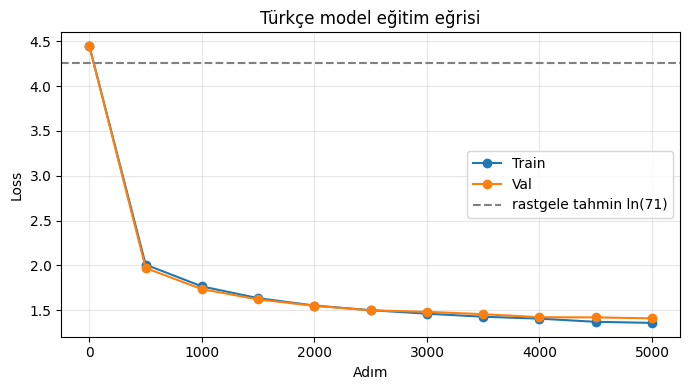

In [7]:
VERI = TR_VERI
tr_model, df_gecmis, tr_final, tr_dk, tr_par = buyuk_egit(TR_VOCAB)
print(f"\nToplam eğitim süresi: {tr_dk:.1f} dk")
print(f"Final (200 batch): train {tr_final['train']:.4f}, val {tr_final['val']:.4f}")
torch.save(tr_model.state_dict(), "turkce_model.pt")

df_gecmis["Train-Val farkı"] = df_gecmis["Val loss"] - df_gecmis["Train loss"]
print("\nEğitim sırasında loss (azaltılmış batch ile ölçüm)")
try:
    display(df_gecmis.style.hide(axis='index').format(
        {"Train loss": "{:.4f}", "Val loss": "{:.4f}", "Süre (dk)": "{:.1f}", "Train-Val farkı": "{:.4f}"}))
except Exception:
    display(df_gecmis)

plt.figure(figsize=(7, 4))
plt.plot(df_gecmis["Adım"], df_gecmis["Train loss"], marker="o", label="Train")
plt.plot(df_gecmis["Adım"], df_gecmis["Val loss"], marker="o", label="Val")
plt.axhline(np.log(TR_VOCAB), color="gray", linestyle="--", label=f"rastgele tahmin ln({TR_VOCAB})")
plt.xlabel("Adım"); plt.ylabel("Loss"); plt.title("Türkçe model eğitim eğrisi")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 8. Modelin ürettiği Türkçe metin

İki örnek üretiyoruz: biri boş bir başlangıçtan, biri `"Bir gün"` ile başlayarak. Her çalıştırmada (seed değişirse) farklı metin çıkar.

In [11]:
tr_model.eval()

def uret(baslangic, n=800, seed=1337):
    torch.manual_seed(seed)
    if baslangic and all(c in TR_STOI for c in baslangic):
        ctx = torch.tensor([[TR_STOI[c] for c in baslangic]], dtype=torch.long, device=device)
    else:
        if baslangic:
            print("(Başlangıç metninde sözlükte olmayan harf var, boş başlangıç kullanıldı.)")
        ctx = torch.zeros((1, 1), dtype=torch.long, device=device)
    return decode_tr(tr_model.generate(ctx, n)[0].tolist())

decode_tr = lambda l: ''.join(TR_ITOS[i] for i in l)

print("=== Örnek 1: boş başlangıç ===")
print(uret(""))
print("\n=== Örnek 2: \"Bir gün\" ile başlangıç ===")
print(uret("Bir gün", seed=42))
_=tr_model.train()


=== Örnek 1: boş başlangıç ===

İbirinci bilgisiz iki yardım Kamaların Anasıl adı korkuyordu. Beni emek zorları kızkardeşi gardece her şeyi çıkardı. Yapmamıştır. Bu nesinleri esmediğimi olayla. Dinleyerek herkes polissi zaman. Yan tanımalıyım yatmak mıydığım şortlar gibi bir düşünceye. Yaçma orada, ne istediği gün genel kırıldamışım. Zaran akıl hele. Her zaman ve bir haklı bir yerde beni. Yazmadıkça vatandığını söyledi. Durmadan hesapların Permanı Turgut, kendisini İs'le devrime belki kimse görüştünüzde geçirir zamanda çizgilinir tarafnıza başvurabileceğiz. Bu kadar kısmı ısrarak uyarım ve bir kafasında yazı olanların kapıya girenç bir defa sokaklarını şöyle hamuna yaklaştırmak istersen gereği hayatının arasına hayallerini aldırmak isteyecek Birşeylerinin Vermiştik bu hastasını cesareten benim için pahala neye kadar olur

=== Örnek 2: "Bir gün" ile başlangıç ===
Bir günlü. Meslik, durumda, sonra parayı onu nasıl biraz kırmıza sokağa boynatlı ve sevmenin de Perman Selim Diğne de Özellik

**Üretilen metin nasıl yorumlanır?** (Çıktına bakarak şu soruları sor)

- **Biçim:** Paragraflar, noktalama, diyalog çizgisi (`—`), büyük harfle başlayan cümleler öğrenilmiş mi?
- **Kelimeler:** Türkçe'ye benzeyen kelimeler var mı? Kelimelerin bir kısmı genellikle **uydurma** olur (gerçekte olmayan ama Türkçe gibi duran). Türkçe'ye özgü harfler (`ç ğ ı ö ş ü`) doğru yerlerde kullanılıyor mu?
- **Ekler:** Türkçe sondan eklemeli bir dildir; model `-lar`, `-den`, `-ında` gibi ek kalıplarını öğrenmiş mi? Bu, harf düzeyinde bir modelin bile yakalayabildiği bir örüntüdür.
- **Anlam:** Cümleler genelde **anlamlı bir bütün oluşturmaz**. Model harf harf çalışır, yaklaşık 1 milyon karakterlik kısa bir veriyle ve birkaç dakika eğitildi; yani anlamı değil, metnin **istatistiksel kalıbını** öğrenir.
- **Kaynak gürültüsü:** OCR'dan kalan hatalar (yanlış harfler, bozuk kelimeler) üretilen metinde de görünebilir; model verideki hataları da öğrenir.

## 9. Shakespeare ve Türkçe sonuçlarını karşılaştır

Tabloda her iki veri seti için aynı ölçüler yan yana verilir:

- **Farklı karakter:** Veri setindeki sözlük boyutu.
- **ln(V):** Hiçbir şey bilmeyen, her harfe eşit olasılık veren modelin loss'u (rastgele tahmin tabanı). Sözlük büyüdükçe artar.
- **Bigram val / GPT val:** Aynı veri üzerinde basit model ve büyük model.
- **Bigram'a göre kazanç:** `bigram val − GPT val`. Aynı veri üzerinde GPT'nin basit modele göre ne kadar iyileştiği.
- **GPT / bigram oranı:** GPT'nin loss'u bigram'ın yüzde kaçı. Küçüldükçe GPT o veride daha çok kazanmış demektir.
- **Bit/karakter:** `val loss / ln 2`. Loss'un bit cinsinden gösterimi (sadece birim değişikliği).

In [9]:
def satir(ad, V, b_val, g_val):
    return {"Veri seti": ad, "Farklı karakter": V, "ln(V) rastgele tahmin": np.log(V),
            "Bigram val": b_val, "GPT val": g_val,
            "Bigram'a göre kazanç": b_val - g_val, "GPT / bigram oranı": g_val / b_val,
            "GPT val (bit/karakter)": g_val / np.log(2)}

df_kars = pd.DataFrame([
    satir("Tiny Shakespeare", SHK["vocab"], SHK["bigram_val"], SHK["gpt_val"]),
    satir("Türkçe (Tutunamayanlar)", TR_VOCAB, tr_bigram["val"], tr_final["val"]),
])
print("KARŞILAŞTIRMA TABLOSU")
try:
    display(df_kars.style.hide(axis='index').format(
        {"ln(V) rastgele tahmin": "{:.3f}", "Bigram val": "{:.4f}", "GPT val": "{:.4f}",
         "Bigram'a göre kazanç": "{:.4f}", "GPT / bigram oranı": "{:.3f}", "GPT val (bit/karakter)": "{:.3f}"}))
except Exception:
    display(df_kars)

s, t = df_kars.iloc[0], df_kars.iloc[1]
print(f"\nGPT val loss: Shakespeare {s['GPT val']:.4f}, Türkçe {t['GPT val']:.4f}  (fark {t['GPT val'] - s['GPT val']:+.4f})")
print(f"Rastgele tahmin tabanı: Shakespeare {s['ln(V) rastgele tahmin']:.3f}, Türkçe {t['ln(V) rastgele tahmin']:.3f}")
kz = "Bigram'a göre kazanç"
print(f"Bigram'a göre kazanç: Shakespeare {s[kz]:.4f}, Türkçe {t[kz]:.4f}")

KARŞILAŞTIRMA TABLOSU


Veri seti,Farklı karakter,ln(V) rastgele tahmin,Bigram val,GPT val,Bigram'a göre kazanç,GPT / bigram oranı,GPT val (bit/karakter)
Tiny Shakespeare,65,4.174,2.4912,1.5510,0.9402,0.623,2.238
Türkçe (Tutunamayanlar),71,4.263,2.5129,1.4072,1.1057,0.560,2.030



GPT val loss: Shakespeare 1.5510, Türkçe 1.4072  (fark -0.1438)
Rastgele tahmin tabanı: Shakespeare 4.174, Türkçe 4.263
Bigram'a göre kazanç: Shakespeare 0.9402, Türkçe 1.1057


## 10. Mailin soruları ve yanıtlar

### Soru 1: Türkçe metnin kaç farklı karakteri var? Shakespeare'inkiyle (65) karşılaştır.

Sayı, yukarıdaki **Tablo 2**'de (veri seti karşılaştırması) ve `Türkçe veri setinde ... farklı karakter var` satırında yazıyor. Türkçe veri setinde Shakespeare'in 65'inden **daha fazla** farklı karakter var. Sebepleri:

- **Türkçe'ye özgü harfler:** `ç ğ ı İ ö ş ü` (ve bazı eserlerde `â`) ve bunların büyük harfleri. Shakespeare'de bunların hiçbiri yok (Tablo 3).
- **Büyük/küçük harf ayrı karakterdir:** Türkçe'de `i/İ` ve `ı/I` çiftleri de ayrı ayrı sayılır.
- **Noktalama farklı:** Romanlarda diyalog çizgisi `—`, tırnak ve üç nokta gibi işaretler sık geçer; oyun metninde (Shakespeare) böyle değil.
- **Rakamlar ve OCR artıkları:** Taranmış kitaplarda rakamlar ve bozuk karakterler olabilir. Nadir karakter filtresiyle çoğunu attık, ama temizlenemeyen birkaçı kalmış olabilir.

Daha fazla karakter, modelin **daha büyük bir çıkış katmanı** (`vocab_size`) ve her karakter için **daha az örnek** görmesi demektir.

### Soru 2: Modelin ürettiği metinden örnek ver.

**Bölüm 8**'deki iki örnek ve altındaki yorum rehberi bunu karşılıyor.

### Soru 3: İki val loss doğrudan karşılaştırılabilir mi? Neden?

**Hayır, doğrudan karşılaştırılamaz.** Val loss, modelin her harfi tahmin ederken yaptığı ortalama hatadır. Bu değer yalnızca modelin kalitesine değil, **verinin kendisine** de bağlıdır. İki veri seti birbirinden şu nedenlerle farklıdır:

1. **Rastgele tahmin tabanı farklı.** Sözlük boyutu farklı olduğu için (65'e karşı daha fazla), hiçbir şey bilmeyen bir modelin loss'u bile `ln(V)` kadar farklıdır. İki veri seti **aynı noktadan** başlamıyor.
2. **Metnin kendi öngörülebilirliği farklı.** Bazı metinlerde bir sonraki harfi tahmin etmek doğası gereği daha kolaydır. Türkçe sondan eklemeli bir dildir (kelimeler uzun, ek zincirleri var), İngilizce Shakespeare dili ise başka bir yapıdadır. Bu fark, loss'un düşük ya da yüksek çıkmasında model kalitesi kadar etkilidir.
3. **Metin türü farklı.** Shakespeare bir **oyun**: kısa satırlar, sürekli tekrar eden karakter adları ve `:` kalıpları (bunlar kolay tahmin edilir ve loss'u düşürür). Bizim veri ise **roman**: uzun paragraflar, serbest anlatım.
4. **Veri kalitesi ve derleme farklı.** Türkçe veri OCR'dan geldi, yani yanlış okunmuş harfler gibi **tutarsız gürültü** içeriyor ve bizim temizliğimizin kalitesine bağlı. Ayrıca roman tek bir yazarın üslubunu taşıyor; doğrulama kısmı da romanın sonundaki bir bölüm olduğu için eğitim kısmından farklı bir konu ve üslup içerebilir.
5. **Seyreklik farklı.** Veri setleri aynı boyutta (yaklaşık 1,1 milyon karakter) olsa da Türkçe'de karakter sayısı fazla olduğu için her karakter ve her karakter çifti için daha az örnek var.
6. **Birim aynı, anlam aynı değil.** Loss'u bit/karakter'e çevirmek sadece birimi değiştirir; verinin zorluğundaki farkı ortadan kaldırmaz.

**Peki neyi adil karşılaştırabiliriz?** Her veri setini **kendi taban çizgisine** göre ölçerek: (a) o verideki **bigram'a göre kazanç** ve **GPT / bigram oranı**, (b) rastgele tahmin tabanı `ln(V)`'ye göre ne kadar aşağı inildiği. Bunlar yukarıdaki karşılaştırma tablosunda var. Yine de bunlar da tam eşdeğer değildir; bu yüzden sonuç "Türkçe model daha iyi / kötü" diye değil, **"her veri setinde model kendi taban çizgisinin ne kadar altına inebildi"** diye yorumlanmalıdır.